In [ ]:
# Helper Functions

import os
import math
import copy
import open3d as o3d
import numpy as np
from scipy.spatial.transform import Rotation as R
import pandas as pd
import re



def get_rotation_matrix_z(deg):
    """Creates a 3x3 rotation matrix for the Z-axis."""
    rad = math.radians(deg)
    c, s = math.cos(rad), math.sin(rad)
    return np.array([[c, -s, 0], 
                     [s,  c, 0], 
                     [0,  0, 1]])


def merge_multiview_scan(data_dir, initial_pos, initial_angle, box_size):
    """Merges multiple view PCDs and removes points below the detected plane."""
    
    pcd_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.pcd')]

    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return int(numbers[0]) if numbers else 0
    
    pcd_files.sort(key=extract_number)
    
    merged_pcd = o3d.geometry.PointCloud()
    
    obb = o3d.geometry.OrientedBoundingBox(
        center=np.array(initial_pos), 
        R=get_rotation_matrix_z(-initial_angle), 
        extent=np.array(box_size)
    )

    test = 0   

    print(f"Found {len(pcd_files)} PCD files. Processing...")

    for file_name in pcd_files:
        pcd = o3d.io.read_point_cloud(os.path.join(data_dir, file_name))
   
        # 1. Detect the plane
        plane_model, inliers = pcd.segment_plane(distance_threshold=3.0, ransac_n=3, num_iterations=2000)
        [a, b, c, d] = plane_model

        # 2. Extract all points as a numpy array
        pts = np.asarray(pcd.points)

        # 3. Calculate distance to plane for every point: ax + by + cz + d
        # Points on the plane result in 0. Points above are positive, below are negative.
        distances = a * pts[:, 0] + b * pts[:, 1] + c * pts[:, 2] + d
        
        # 4. Create an index of points that are ABOVE the plane
        # A small offset (e.g., 0.5mm) to avoid keeping table noise
        above_plane_indices = np.where(distances > 0.5)[0]
        pcd = pcd.select_by_index(above_plane_indices)


        # 5. Crop to the OBB and merge
        if test == 0:            
            # create frame
            frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20)
            frame.transform(T_base2ob_yolo)

            o3d.visualization.draw_geometries([pcd, obb, frame], window_name=f"Filtered Cloud - {file_name}")
            test += 1

        merged_pcd += pcd.crop(obb)

    # frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20)
    # frame.transform(T_base2ob_yolo)
    # o3d.visualization.draw_geometries([merged_pcd, obb, frame], window_name=f"Filtered Cloud - {file_name}")

    return merged_pcd



def process_point_cloud(pcd, initial_pos, initial_angle, box_size):
    """Processes a single PCD file: removes ground plane and crops to OBB."""
    distance_threshold = 3.0 # mm, for RANSAC plane segmentation
    ransac_n = 3
    num_iterations = 2000
    plane_offset = 0.5 # mm, to ensure we keep points just above the plane

    # 1. Load the specific file    
    if pcd.is_empty():
        print(f"Warning: Point cloud is empty or not found.")
        return pcd

    # 2. Define the Oriented Bounding Box (OBB)
    # Using your rotation logic to align with the YOLO/Initial guess
    rot_matrix = get_rotation_matrix_z(-initial_angle) 
    obb = o3d.geometry.OrientedBoundingBox(
        center=np.array(initial_pos), 
        R=rot_matrix, 
        extent=np.array(box_size)
    )

    # 3. Detect and remove the ground plane (RANSAC)
    plane_model, inliers = pcd.segment_plane(distance_threshold=distance_threshold, 
                                             ransac_n=ransac_n, 
                                             num_iterations=num_iterations)
    [a, b, c, d] = plane_model

    # 4. Filter points above the plane
    pts = np.asarray(pcd.points)
    # ax + by + cz + d > offset
    distances = a * pts[:, 0] + b * pts[:, 1] + c * pts[:, 2] + d
    above_plane_indices = np.where(distances > plane_offset)[0] 
    pcd_filtered = pcd.select_by_index(above_plane_indices)
    # 5. Crop to the region of interest
    # o3d.visualization.draw_geometries([final_pcd, obb], window_name="Downsampled Clouds with Normals")
    final_pcd = pcd_filtered.crop(obb)

    return final_pcd


def load_viewpoint_data(actual_dir, sim_dir):
    """
    Loads all actual and simulated point clouds automatically.

    Args:
        actual_dir (str): Path to 'pcd_data' folder
        sim_dir (str): Path to 'viewpoints_candidate' folder

    Returns:
        target_clouds (list): list of actual point clouds
        source_clouds (list): list of simulated point clouds
    """

    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return int(numbers[0]) if numbers else 0

    target_clouds = []
    source_clouds = []


    # find all actual viewpoint files
    actual_files = [f for f in os.listdir(actual_dir) if f.endswith(".pcd")]
    actual_files.sort(key=extract_number)


    for file in actual_files:

        print(f"Processing: {file}") # This will show you the culprit

        # extract index from filename (view00.pcd -> 0)
        index = int(file.replace("view", "").replace(".pcd", ""))

        sim_name = f"viewpoint_simulated_{index}.pcd"

        actual_path = os.path.join(actual_dir, file)
        sim_path = os.path.join(sim_dir, sim_name)

        try:
            actual_pcd = o3d.io.read_point_cloud(actual_path)
            sim_pcd = o3d.io.read_point_cloud(sim_path)

            target_clouds.append(actual_pcd)
            source_clouds.append(sim_pcd)

        except Exception as e:
            print(f"Error loading index {index}: {e}")

    return target_clouds, source_clouds


def pose_to_matrix(pose):
    """
    Converts [x, y, z, roll, pitch, yaw] in degrees to a 4x4 transformation matrix.
    If zyz=True, assumes the input is in ZYZ Euler Angles, otherwise XYZ Euler Angles.
    
    Args:
    - pose (list or array): [x, y, z, roll, pitch, yaw] in degrees.
    - zyz (bool): If True, interprets the last three values as ZYZ Euler angles. 
                  If False, uses XYZ Euler angles (default).
    
    Returns:
    - T (ndarray): The 4x4 homogeneous transformation matrix.
    """
    x, y, z = pose[:3]   # Translation vector
    roll, pitch, yaw = pose[3:]  # Rotation angles in degrees
    
    # Convert XYZ Euler Angles to a 3x3 rotation matrix
    rot_matrix = R.from_euler('xyz', [roll, pitch, yaw], degrees=True).as_matrix()

    # Build the 4x4 Homogeneous Transformation Matrix
    T = np.eye(4)  # Start with the identity matrix (4x4)
    T[:3, :3] = rot_matrix  # Set the upper-left 3x3 part to the rotation matrix
    T[:3, 3] = [x, y, z]    # Set the upper-right 3x1 part to the translation vector
    return T


def preprocess_normal(pcd, num_points=False, invert_normals=False, radius=2, max_nn=30):
    """Downsamples, estimates normals, and computes FPFH features."""
    if num_points:
        current_num_points = len(pcd.points)
        
        if current_num_points >= num_points:
            # Downsample if we have more points than needed
            pcd_down = pcd.farthest_point_down_sample(num_points)
        else:
            # Extrapolate if we have fewer points than needed
            pcd_down = o3d.geometry.PointCloud(pcd) # Copy original
            
            # Calculate how many extra points we need
            num_to_pad = num_points - current_num_points
            
            # Randomly select indices to duplicate (with replacement)
            indices = np.arange(current_num_points)
            pad_indices = np.random.choice(indices, size=num_to_pad, replace=True)
            
            # Extract points and normals
            orig_xyz = np.asarray(pcd.points)
            pad_xyz = orig_xyz[pad_indices]
            
            # Add subtle jittering to the extrapolated points to avoid exact duplicates
            # 0.001 assumes your data is in meters (1mm jitter)
            jitter = np.random.normal(0, 0.001, pad_xyz.shape)
            pad_xyz += jitter
            
            # Combine original and extrapolated points
            final_xyz = np.vstack((orig_xyz, pad_xyz))
            pcd_down.points = o3d.utility.Vector3dVector(final_xyz)
            
            # If the original cloud already had normals, pad them too
            if pcd.has_normals():
                orig_normals = np.asarray(pcd.normals)
                pad_normals = orig_normals[pad_indices]
                final_normals = np.vstack((orig_normals, pad_normals))
                pcd_down.normals = o3d.utility.Vector3dVector(final_normals)
    else:
        pcd_down = pcd
        
    avg_dist = np.mean(pcd_down.compute_nearest_neighbor_distance())
    
    # Estimate Normals
    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * radius, max_nn=max_nn))
    
    # Orientation fix: Ensure normals point 'up' (positive Z)
    normals = np.asarray(pcd_down.normals)
    
    if invert_normals:
        for i in range(len(normals)):
            if normals[i][2] < 0:
                normals[i] *= -1

    # Compute FPFH (Feature descriptors for global matching)
    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down, o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * 5, max_nn=100))
    
    return pcd_down, fpfh


def run_global_registration(source, target, source_fpfh, target_fpfh, voxel_size):
    """
    Performs RANSAC-based global registration to find a rough alignment.
    """
    distance_threshold = voxel_size * 1.5
    
    # RANSAC based on feature matching
    result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source, target, source_fpfh, target_fpfh, 
        mutual_filter=True,
        max_correspondence_distance=distance_threshold,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        ransac_n=3, 
        checkers=[
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
        ], 
        criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
    )
    return result


def run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh):
    """
    Performs iterative RANSAC-based global registration to find the best rough alignment.
    Matches the logic of testing multiple thresholds to find the highest fitness and lowest RMSE.
    """
    max_attempts = 5
    best_fitness = -0.1
    best_inlier_rmse = 100.0
    best_result = None
    best_threshold = None 

    # Thresholds to test, from coarse (10.0) to fine (3.0)
    thresholds = [10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0]
    # thresholds = [7]

    for attempt in range(max_attempts):
        for thr in thresholds:            
            result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
                source_down, target_down, source_fpfh, target_fpfh, 
                mutual_filter=True, # Improved matching
                max_correspondence_distance=thr,
                estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
                ransac_n=3, 
                checkers=[
                    o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.85),
                    o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(thr)
                ], 
                criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(10000, 0.99)
            )

            # Update best result if fitness is good and RMSE is lower
            if result.fitness > 0.85 and result.inlier_rmse < best_inlier_rmse:
                best_fitness = result.fitness
                best_inlier_rmse = result.inlier_rmse
                best_result = result
                best_threshold = thr
            
            # Early exit if we find a very high-quality match
            if best_fitness > 0.95 and best_inlier_rmse < 2.35: 
                print(f"Excellent Global Fit Found at Threshold {best_threshold}")
                return best_result, best_threshold
            
    if best_result is None:
        print("Warning: RANSAC could not find a fit above 0.85 fitness.")
        # Fallback to the last result generated if nothing met the 0.85 criteria
        return result, thr

    print(f"RANSAC Finished. Best Threshold: {best_threshold} | Fitness: {best_fitness:.4f}")
    return best_result, best_threshold


# One time local refinement using ICP
def run_local_refinement(source, target, initial_transformation=None, voxel_size=1.0):
    """
    Performs ICP registration to refine the alignment found by RANSAC.
    """
    if initial_transformation is None:
        initial_transformation = np.eye(4)
        
    # We use a smaller threshold for ICP to ensure high precision
    distance_threshold = voxel_size * 0.4
    
    result = o3d.pipelines.registration.registration_icp(
        source, target, distance_threshold, initial_transformation,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=2000)
    )
    return result


# Progressive Local Refinement using ICP
def run_local_refinement_adaptive(source, target, initial_trans=None, best_ransac_thr=10, method="point_to_point"):
    """
    Refines alignment using an iterative ICP loop. 
    Starts with a coarse threshold and progressively tightens for precision.
    Supports both point-to-point and point-to-plane ICP.
    """

    if initial_trans is None:
        initial_trans = np.eye(4)
        
    # Define a range of multipliers to tighten the search radius
    multipliers = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
    thresholds = [best_ransac_thr * m for m in multipliers]
    
    best_result = None
    best_inlier_rmse = float('inf') # Start with the highest possible error
    
    # Choose ICP Estimation Method
    if method == "point_to_plane":
        estimation_method = o3d.pipelines.registration.TransformationEstimationPointToPlane()
        print("Using Point-to-Plane ICP")
    else:
        estimation_method = o3d.pipelines.registration.TransformationEstimationPointToPoint()
        print("Using Point-to-Point ICP")
    0,
    print(f"{'Threshold':<12} | {'Fitness':<12} | {'RMSE':<12}")
    print("-" * 45)

    for thr in thresholds:
        # Execute ICP
        reg_icp = o3d.pipelines.registration.registration_icp(
            source, target, thr, initial_trans,
            estimation_method,
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=1000)
        )

        # Logging the current iteration results
        print(f"{thr:<12.2f} | {reg_icp.fitness:<12.4f} | {reg_icp.inlier_rmse:<12.4f}")

        # Selection Logic: Prioritize lowest RMSE (highest precision) 
        # as long as the fitness is acceptable (e.g., > 85%)
        if reg_icp.fitness > 0.85 and reg_icp.inlier_rmse < best_inlier_rmse:
            best_inlier_rmse = reg_icp.inlier_rmse
            best_result = reg_icp

    # Fallback: if no run met the 85% fitness, return the last result
    return best_result if best_result is not None else reg_icp


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [22]:
# Create a initial alignment from every viewpoint

# --- 1. Configuration ---
NUMBER_OF_POINTS = 40000
EXPERIMENT = "test_11_grasp"
SOURCE_PATH = "workpiece/workpiece31/workpiece.stl" #  CAD STL model

DATA_DIR = f"pcd_data/testing_data/{EXPERIMENT}" # Multiview scans
SOURCE_DIR = f"viewpoints_candidate/testing_data/{EXPERIMENT}"

tf_obj = np.load(os.path.join(DATA_DIR, 'initial_obj_pose.npy'))
T_base2ob_yolo = np.load(os.path.join(DATA_DIR, 'T_base2ob_yolo.npy'))

# kebutuhan motong 1 (tidak tervisualisasi)
T_base2ob_yolo[0,3] -= 0 # 10
T_base2ob_yolo[1,3] -= 0 # 2.5
# T_base2ob_yolo[2,3] += 55

YOLO_POS = tf_obj[:3]                                   # Initial guess from YOLO
YOLO_ANGLE = tf_obj[4]                                  # Initial angle from YOLO
# CROP_BOX = [85, 65, 75]                               # ROI wp1
# CROP_BOX = [110, 90, 85]                               # ROI Obj31 // wp2
# CROP_BOX = [75, 75, 60]                               # ROI square_flange // wp3
CROP_BOX = [85, 105, 60]                               # ROI wp31 // wp3

# kebutuhan motong 2 (buat visualisasi awal)
YOLO_POS[0] -= 0 # 10
YOLO_POS[1] -= 0 # 2.5
YOLO_POS[2] -= 0 # Shift this if the CROP_BOX is accidentally cutting off the top or bottom of your object!

# --- 2. Data Preparation ---
mesh = o3d.io.read_triangle_mesh(SOURCE_PATH)
mesh.compute_vertex_normals()

# --- OPTITRACK ALIGNMENT FIX ---
# If your CAD model's native X/Y axes are 90 degrees off from your physical OptiTrack markers, 
# ICP will output an ~88 degree Yaw to make them fit. 
# You can permanently rotate the CAD geometry here so it natively matches the OptiTrack definition!

R_correct = mesh.get_rotation_matrix_from_xyz((0, 0, np.radians(-90))) # Try 90 or -90
mesh.rotate(R_correct, center=(0, 0, 0))

# Multiview
source_cloud = mesh.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)
# Simulated view
# source_cloud = o3d.io.read_point_cloud(os.path.join('viewpoints_candidate/testing_data',EXPERIMENT,'viewpoint_simulated_0.pcd')) # <-- Commented out so it defaults to the CAD mesh!

full_target_cloud = merge_multiview_scan(DATA_DIR, YOLO_POS, YOLO_ANGLE, CROP_BOX)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[0, 0, 0])
o3d.visualization.draw_geometries([full_target_cloud, mesh, world_frame], window_name="Merged Target Cloud")



# Manual Initial Guess
T_extra = np.eye(4)

# Define 90 degrees around Z (adjust axis as needed: 'x', 'y', or 'z')
r = R.from_euler('z', -90, degrees=True)
T_extra[:3, :3] = r.as_matrix()

x_offset = 0.0
y_offset = 0.0 
z_offset = 0.0 #-11.197 # <-- If CAD origin is at the bottom, set this to shift the CAD down (e.g. -40) to match YOLO!

T_extra[:3, 3] = [x_offset, y_offset, z_offset]

T_initial_guess = T_base2ob_yolo @ T_extra


# 3. Preprocess Normal
# source_cloud_transformed = copy.deepcopy(source_cloud)
source_cloud_transformed = copy.deepcopy(source_cloud).transform(T_initial_guess)
source_down, source_fpfh = preprocess_normal(source_cloud_transformed)
target_down, target_fpfh = preprocess_normal(full_target_cloud, num_points=40000, invert_normals=True)

source_down.paint_uniform_color([1, 0, 0])
target_down.paint_uniform_color([0, 0.651, 0.929])
o3d.visualization.draw_geometries([target_down, source_down], window_name="Processed Target Cloud")
# o3d.visualization.draw_geometries([target_down], window_name="Processed Target Cloud")




Found 17 PCD files. Processing...


In [6]:
o3d.visualization.draw_geometries([target_down, source_down], window_name="Processed Target Cloud")



In [3]:

viz = []

viz.append(target_down)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[0, 0, 0])
viz.append(world_frame)
world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[100, 0, 0])
viz.append(world_frame)

o3d.visualization.draw_geometries(viz, window_name="Processed Target Cloud")


In [ ]:
# --- 3. Global Alignment (RANSAC) ---
print("Step 2: Running RANSAC Global Registration...")
ransac_res, best_thr = run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh)
print(ransac_res)

# Visualize RANSAC result
source_temp = copy.deepcopy(source_down)
source_temp.transform(ransac_res.transformation)
source_temp.paint_uniform_color([1, 0, 0])
target_down.paint_uniform_color([0, 0.651, 0.929])


In [23]:
# --- 4. Local Alignment (ICP) ---
print("Step 3: Running ICP Local Refinement...")
# icp_res = run_local_refinement_adaptive(source_down, target_down, ransac_res.transformation, best_thr) #icp from ransac
icp_res = run_local_refinement_adaptive(source_down, target_down, method="point_to_point") #icp only
# icp_res = run_local_refinement(source_down, target_down, voxel_size=9)  # source, target, initial_transformation, voxel_size # icp non adaptive
# run_local_refinement

print(icp_res)

# --- 5. Extract Final Results ---
fine_correction_transformation = icp_res.transformation # just the final ICP result
# merge_full_transformation = fine_correction_transformation
merge_full_transformation = np.dot(fine_correction_transformation, T_initial_guess) # Combine the initial YOLO-based transformation with the final ICP correction

print("="*30)
print("--- Final Workpiece Pose (Robot Base = Origin) ---")

# Print 4x4 matrix with scientific formatting
np.set_printoptions(formatter={'float': lambda x: f"{x:8.3e}"})
print(merge_full_transformation)
np.set_printoptions() # Reset to default

initial_POS = merge_full_transformation[:3, 3] 
initial_ORI = merge_full_transformation[:3, :3] 

# Convert Rotation Matrix to Euler angles (XYZ)
euler = R.from_matrix(initial_ORI).as_euler('xyz', degrees=True)

# Format translations (assuming the original values are in millimeters, convert to meters)
pos_m = initial_POS / 1000.0

print(f"\nTranslation (X, Y, Z) in meters: {pos_m[0]:.4f}, {pos_m[1]:.4f}, {pos_m[2]:.4f}")
print(f"Rotation (Roll, Pitch, Yaw) in degrees: {euler[0]:.2f}, {euler[1]:.2f}, {euler[2]:.2f}")
print(f"Fitness: {icp_res.fitness:.4f}")
print(f"RMSE: {icp_res.inlier_rmse:.4f}")


# --- 6. Final Visualization ---
source_final = copy.deepcopy(source_cloud).transform(merge_full_transformation)
source_final.paint_uniform_color([1, 0, 0])         # Red: CAD Model
full_target_cloud.paint_uniform_color([0, 0.65, 0.93])   # Blue: Scanned Data
o3d.visualization.draw_geometries([source_final, full_target_cloud])

# Save the final transformation for use in the evaluation step
FULL_TRANSFORM_SAVE_DIR = f'evaluation_result/{EXPERIMENT}/merge_full_transformation.npy'
dir_name = os.path.dirname(FULL_TRANSFORM_SAVE_DIR)
if not os.path.exists(dir_name):
    os.makedirs(dir_name)

# Save the file


Step 3: Running ICP Local Refinement...
Using Point-to-Point ICP
Threshold    | Fitness      | RMSE        
---------------------------------------------
10.00        | 0.7987       | 5.3222      
9.00         | 0.7484       | 4.9167      
8.00         | 0.6316       | 3.9100      
7.00         | 0.5688       | 3.2682      
6.00         | 0.5209       | 2.7880      
5.00         | 0.4696       | 2.3017      
4.00         | 0.4153       | 1.8263      
3.00         | 0.3596       | 1.3975      
2.00         | 0.2845       | 0.9837      
1.00         | 0.1961       | 0.6334      
RegistrationResult with fitness=1.961000e-01, inlier_rmse=6.333540e-01, and correspondence_set size of 7844
Access transformation to get result.
--- Final Workpiece Pose (Robot Base = Origin) ---
[[9.995e-01 2.935e-02 -7.648e-03 5.086e+02]
 [-2.937e-02 9.996e-01 -2.728e-03 -1.085e+02]
 [7.565e-03 2.951e-03 1.000e+00 7.954e+00]
 [0.000e+00 0.000e+00 0.000e+00 1.000e+00]]

Translation (X, Y, Z) in meters: 0.5086, -

In [6]:
# Load the PC



Processing: view0.pcd
Processing: view1.pcd
Processing: view2.pcd
Processing: view3.pcd
Processing: view4.pcd
Processing: view5.pcd
Processing: view6.pcd
Processing: view7.pcd
Processing: view8.pcd
Processing: view9.pcd
Processing: view10.pcd
Processing: view11.pcd
Processing: view12.pcd
Processing: view13.pcd
Processing: view14.pcd
Processing: view15.pcd
Processing: view16.pcd
Processing: view17.pcd
Processing: view18.pcd
Processing: view19.pcd
Processing: view20.pcd
Processing: view21.pcd
Processing: view22.pcd
Processing: view23.pcd


In [7]:
# Configuration and Directories
PROCESSED_SAVE_DIR = f"processed_data/{EXPERIMENT}/"
os.makedirs(PROCESSED_SAVE_DIR, exist_ok=True)

merge_full_transformation = np.load(f'evaluation_result/{EXPERIMENT}/merge_full_transformation.npy')

# Data preparation
# target_clouds, source_clouds = load_viewpoint_data(DATA_DIR, SOURCE_DIR)
results_list = []


# For Testing one viewpoint
# idx = 5
# # o3d.visualization.draw_geometries([target_clouds[idx]]) ## TWO ## from loader

# target_cloud = process_point_cloud(target_clouds[idx], YOLO_POS, YOLO_ANGLE, CROP_BOX)
# target_cloud , _ = preprocess_normal(target_cloud, invert_normals=True, radius=3, max_nn=20)
# source_cloud_transformed = copy.deepcopy(source_clouds[idx]).transform(merge_full_transformation)

# source_cloud_transformed.paint_uniform_color([1, 0, 0])
# target_cloud.paint_uniform_color([0, 0.651, 0.929])
# o3d.visualization.draw_geometries([target_cloud])

## o3d.io.write_point_cloud(f"processed_data/view{idx}.pcd", target_cloud)


# Full alignment on each viewpoint
for i in range(len(target_clouds)):
    # Process the real scan (Crop & Clean)
    target_cloud = process_point_cloud(target_clouds[i], YOLO_POS, YOLO_ANGLE, CROP_BOX)
    target_cloud , _ = preprocess_normal(target_cloud, invert_normals=True, radius=3, max_nn=20)
    
    # Transform the CAD (Source) to the expected pose
    source_cloud_transformed = copy.deepcopy(source_clouds[i]).transform(merge_full_transformation)

    # 1. Save processed target_cloud to .pcd
    filename = f"viewpoint_simulated_{i}.pcd"
    save_path = os.path.join(PROCESSED_SAVE_DIR, filename)
    o3d.io.write_point_cloud(save_path, target_cloud)

    # 2. Compute Metrics
    # Distance from CAD to Real Scan
    dist_s2r_array = np.asarray(source_cloud_transformed.compute_point_cloud_distance(target_cloud))
    dist_s2r = dist_s2r_array.mean()
    
    # Distance from Real Scan to CAD
    dist_r2s_array = np.asarray(target_cloud.compute_point_cloud_distance(source_cloud_transformed))
    dist_r2s = dist_r2s_array.mean()
    
    # Main Regression Targets
    chamfer_value = dist_s2r + dist_r2s
    asymmetry_value = abs(dist_s2r - dist_r2s)

    print(f"Saving viewpoint {i}:")
    # 3. Store results for CSV
    results_list.append({
        'filename': filename,
        'dist_s2r': dist_s2r,
        'dist_r2s': dist_r2s,
        'chamfer_value': chamfer_value,
        'asymmetry_value': asymmetry_value
    })

# --- 4. Save Metadata ---
csv_path = os.path.join(PROCESSED_SAVE_DIR, "metadata.csv")
df = pd.DataFrame(results_list)
df.to_csv(csv_path, index=False)

print(f"\nEvaluation Complete!")


Saving viewpoint 0:
Saving viewpoint 1:
Saving viewpoint 2:
Saving viewpoint 3:
Saving viewpoint 4:
Saving viewpoint 5:
Saving viewpoint 6:
Saving viewpoint 7:
Saving viewpoint 8:
Saving viewpoint 9:
Saving viewpoint 10:
Saving viewpoint 11:
Saving viewpoint 12:
Saving viewpoint 13:
Saving viewpoint 14:
Saving viewpoint 15:
Saving viewpoint 16:
Saving viewpoint 17:
Saving viewpoint 18:
Saving viewpoint 19:
Saving viewpoint 20:
Saving viewpoint 21:
Saving viewpoint 22:
Saving viewpoint 23:

Evaluation Complete!
PCD files and metadata saved to: processed_data/test_6_noise/


In [8]:
o3d.visualization.draw_geometries([target_clouds[1]])


Loading and processing point clouds from pcd_data/testing_data/test_3_dofconsistency_15_test...
Found 5 viewpoints: [0, 1, 2, 3, 4]

Computing Full Pairwise Chamfer Matrix for 5 valid views (10 unique pairs)...
--- Processing Pair (0, 1) ---
RANSAC Finished. Best Threshold: 4.0 | Fitness: 0.8603
  Rep 1/3 - Fit: 0.17, RMSE: 0.57, Chamfer: 4.24
RANSAC Finished. Best Threshold: 4.0 | Fitness: 0.8802
  Rep 2/3 - Fit: 0.18, RMSE: 0.58, Chamfer: 4.19
RANSAC Finished. Best Threshold: 4.0 | Fitness: 0.8906
  Rep 3/3 - Fit: 0.28, RMSE: 0.54, Chamfer: 3.82
  => Avg Chamfer (0, 1): 4.08

--- Processing Pair (0, 2) ---
RANSAC Finished. Best Threshold: 6.0 | Fitness: 0.8818
  Rep 1/3 - Fit: 0.13, RMSE: 0.60, Chamfer: 5.62
RANSAC Finished. Best Threshold: 5.0 | Fitness: 0.8812
  Rep 2/3 - Fit: 0.17, RMSE: 0.60, Chamfer: 4.81
RANSAC Finished. Best Threshold: 6.0 | Fitness: 0.9267
  Rep 3/3 - Fit: 0.19, RMSE: 0.59, Chamfer: 4.02
  => Avg Chamfer (0, 2): 4.82

--- Processing Pair (0, 3) ---
Excellent 

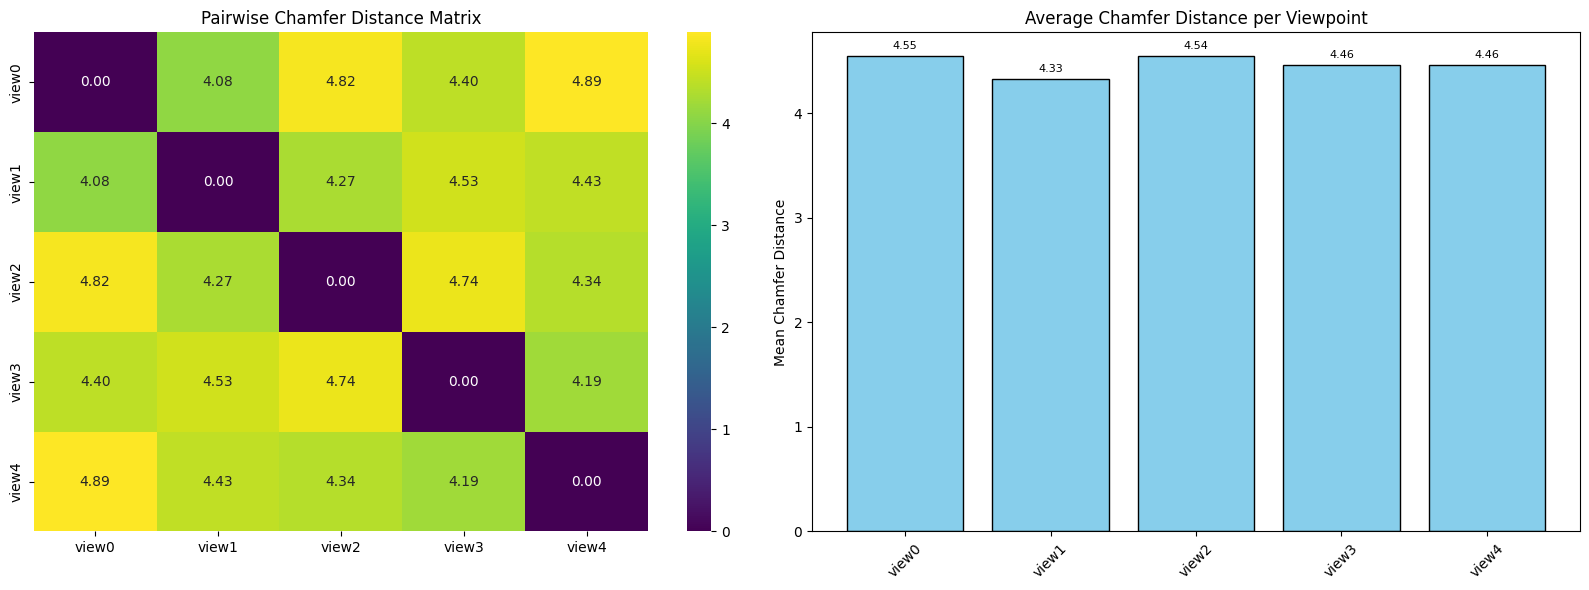

,Mean_Chamfer_Difference
view0,4.547205
view2,4.543668
view3,4.464267
view4,4.461956
view1,4.327805


In [129]:
# --- 7. Full Pairwise Chamfer Distance Matrix & Visual Debugging ---
import itertools
import copy
import numpy as np
import open3d as o3d
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

# Configuration
PAIRWISE_DIR = "pcd_data/testing_data/test_3_dofconsistency_15_test"
REPETITIONS = 3 # Number of times to run RANSAC+ICP per pair

print(f"Loading and processing point clouds from {PAIRWISE_DIR}...")

# 1. Dynamically find all view* .pcd files in the flat directory
pcd_files = glob.glob(os.path.join(PAIRWISE_DIR, "view*.pcd"))
indices = []
for f in pcd_files:
    basename = os.path.basename(f)
    idx_str = basename[4:-4] # "viewX.pcd" -> "X"
    if idx_str.isdigit():
        indices.append(int(idx_str))

indices.sort()
print(f"Found {len(indices)} viewpoints: {indices}")

# 2. Load the single, global initial object pose
tf_obj_path = os.path.join(PAIRWISE_DIR, 'initial_obj_pose.npy')
if os.path.exists(tf_obj_path):
    tf_obj = np.load(tf_obj_path)
    yolo_pos = tf_obj[:3]
    yolo_angle = tf_obj[4]
else:
    print("Warning: initial_obj_pose.npy not found. Cropping may fail.")
    yolo_pos = None
    yolo_angle = None

clouds = {}

for i in indices:
    pcd_path = os.path.join(PAIRWISE_DIR, f"view{i}.pcd")
    pcd = o3d.io.read_point_cloud(pcd_path)
    
    try:
        if yolo_pos is not None and yolo_angle is not None:
            pcd = process_point_cloud(pcd, yolo_pos, yolo_angle, CROP_BOX)
        pcd, _ = preprocess_normal(pcd, invert_normals=True)
        clouds[i] = pcd
    except Exception as e:
        print(f"Warning processing view {i}: {e}")

valid_indices = list(clouds.keys())
valid_indices.sort()
n = len(valid_indices)
chamfer_matrix = np.zeros((n, n))

best_alignments = {}

print(f"\nComputing Full Pairwise Chamfer Matrix for {n} valid views ({n*(n-1)//2} unique pairs)...")
for i, j in itertools.combinations_with_replacement(valid_indices, 2):
    if i == j:
        chamfer_matrix[valid_indices.index(i), valid_indices.index(j)] = 0.0
        continue
        
    chamfer_sum = 0.0
    best_icp_fitness = -1.0
    
    print(f"--- Processing Pair ({i}, {j}) ---")
    
    for rep in range(REPETITIONS):
        source = copy.deepcopy(clouds[i])
        target = copy.deepcopy(clouds[j])
        
        source_down, source_fpfh = preprocess_normal(source)
        target_down, target_fpfh = preprocess_normal(target)
        
        ransac_res, best_thr = run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh)
        source.transform(ransac_res.transformation)
        
        icp_res = run_local_refinement(source, target, voxel_size=2.0)
        source.transform(icp_res.transformation)
        
        dist_s2t = np.asarray(source.compute_point_cloud_distance(target)).mean()
        dist_t2s = np.asarray(target.compute_point_cloud_distance(source)).mean()
        
        chamfer_dist = dist_s2t + dist_t2s
        chamfer_sum += chamfer_dist
        
        print(f"  Rep {rep+1}/{REPETITIONS} - Fit: {icp_res.fitness:.2f}, RMSE: {icp_res.inlier_rmse:.2f}, Chamfer: {chamfer_dist:.2f}")
        
        if icp_res.fitness > best_icp_fitness:
            best_icp_fitness = icp_res.fitness
            best_alignments[(i, j)] = {
                'source': copy.deepcopy(source),
                'target': copy.deepcopy(target),
                'fitness': icp_res.fitness
            }
            
    avg_chamfer = chamfer_sum / REPETITIONS
    idx_i = valid_indices.index(i)
    idx_j = valid_indices.index(j)
    chamfer_matrix[idx_i, idx_j] = avg_chamfer
    chamfer_matrix[idx_j, idx_i] = avg_chamfer
    
    print(f"  => Avg Chamfer ({i}, {j}): {avg_chamfer:.2f}\n")

# --- VISUALIZATION 1: Statistical Metrics ---
df_chamfer = pd.DataFrame(chamfer_matrix, index=[f"view{i}" for i in valid_indices], columns=[f"view{i}" for i in valid_indices])

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(df_chamfer, annot=True, cmap="viridis", fmt=".2f")
plt.title(f"Pairwise Chamfer Distance Matrix")

mean_chamfer_per_view = chamfer_matrix.sum(axis=1) / (n - 1)

plt.subplot(1, 2, 2)
bars = plt.bar([f"view{i}" for i in valid_indices], mean_chamfer_per_view, color='skyblue', edgecolor='black')
plt.title(f"Average Chamfer Distance per Viewpoint")
plt.ylabel("Mean Chamfer Distance")
plt.xticks(rotation=45)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Geometric Alignments (45 Deg Isometric View) ---
# print("Generating Isometric 3D Projections for all pairs...")
# pairs = list(best_alignments.keys())
# cols = 5
# rows = int(np.ceil(len(pairs) / cols))

# fig = plt.figure(figsize=(25, 6 * rows))

# for idx, (i, j) in enumerate(pairs):
#     ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
    
#     s_plot = best_alignments[(i,j)]['source'].voxel_down_sample(voxel_size=1.5)
#     t_plot = best_alignments[(i,j)]['target'].voxel_down_sample(voxel_size=1.5)
    
#     pts_s = np.asarray(s_plot.points)
#     pts_t = np.asarray(t_plot.points)
    
#     if len(pts_t) > 0:
#         ax.scatter(pts_t[:, 0], pts_t[:, 1], pts_t[:, 2], s=1, c='#00A6ED', alpha=0.3, label=f'view{j}')
#     if len(pts_s) > 0:
#         ax.scatter(pts_s[:, 0], pts_s[:, 1], pts_s[:, 2], s=1, c='#FF0000', alpha=0.3, label=f'view{i}')
        
#     ax.set_title(f"Pair ({i}, {j}) | Fit: {best_alignments[(i,j)]['fitness']:.2f}")
#     ax.view_init(elev=45, azim=45)
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_zticks([])

# plt.suptitle(f"Isometric Alignment Check: {PAIRWISE_DIR}", fontsize=18)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

df_summary = pd.DataFrame({"Mean_Chamfer_Difference": mean_chamfer_per_view}, index=[f"view{i}" for i in valid_indices])
df_summary.sort_values(by="Mean_Chamfer_Difference", ascending=False, inplace=True)
display(df_summary)


Loading and processing point clouds from pcd_data/testing_data/test_2_rotationconsistency...
Computing Pairwise Chamfer Distance Matrix by centering everything at the origin...
Pair (0, 1) - Chamfer: 10.48
Pair (0, 2) - Chamfer: 10.49
Pair (0, 3) - Chamfer: 9.48
Pair (0, 4) - Chamfer: 16.17
Pair (1, 2) - Chamfer: 6.99
Pair (1, 3) - Chamfer: 7.35
Pair (1, 4) - Chamfer: 8.98
Pair (2, 3) - Chamfer: 5.34
Pair (2, 4) - Chamfer: 8.37
Pair (3, 4) - Chamfer: 8.65


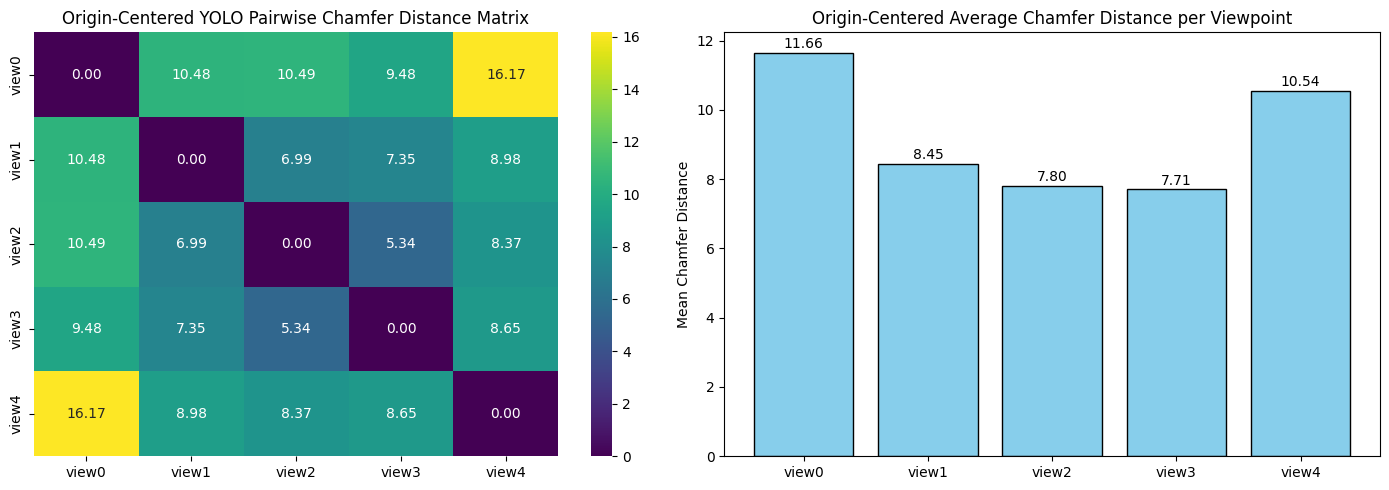

Generating Isometric 3D Projections at the origin...


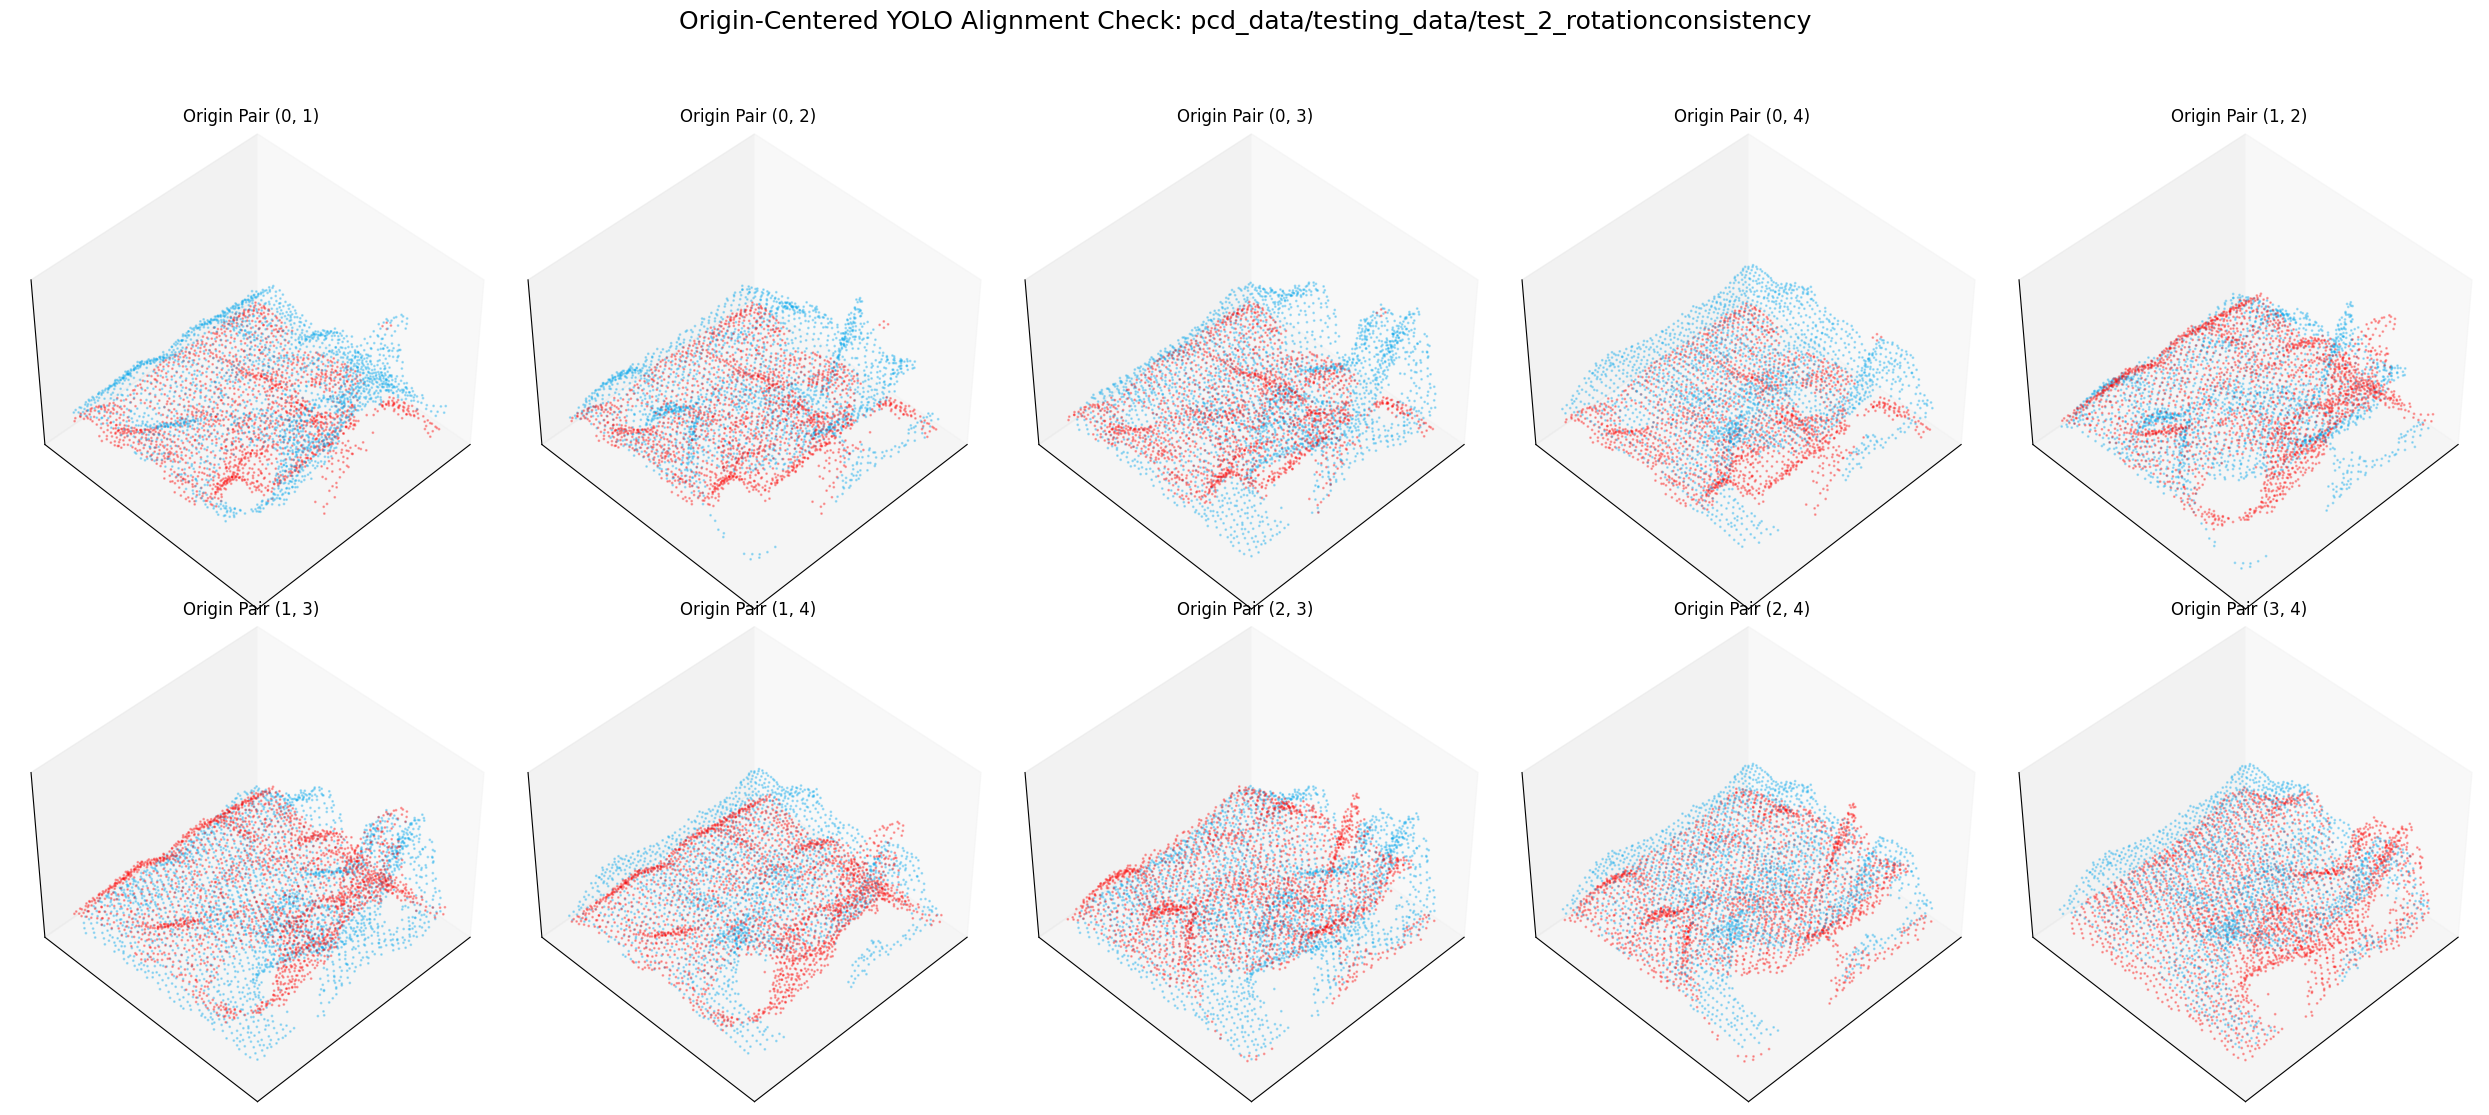


Viewpoints ranked by how different they are from the rest (ORIGIN CENTERED):


,Mean_Chamfer_Difference
view0,11.656043
view4,10.543149
view1,8.450413
view2,7.797279
view3,7.706475


In [ ]:
# --- 8. YOLO-Only Registration (Origin-Centered) ---
import itertools
import copy
import numpy as np
import open3d as o3d
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configuration
PAIRWISE_DIR = "pcd_data/testing_data/test_2_rotationconsistency"
indices = [0, 1, 2, 3]
clouds = {}
yolo_transforms = {}

print(f"Loading and processing point clouds from {PAIRWISE_DIR}...")
for i in indices:
    pcd_path = os.path.join(PAIRWISE_DIR, str(i), f"view{i}.pcd")
    if not os.path.exists(pcd_path):
        continue
    pcd = o3d.io.read_point_cloud(pcd_path)
    
    tf_obj = np.load(os.path.join(PAIRWISE_DIR, str(i), 'initial_obj_pose.npy'))
    try:
        pcd = process_point_cloud(pcd, tf_obj[:3], tf_obj[4], CROP_BOX)
        pcd, _ = preprocess_normal(pcd, invert_normals=True)
    except Exception as e:
        print(f"Warning processing view {i}: {e}")
        
    clouds[i] = pcd
    yolo_transforms[i] = np.load(os.path.join(PAIRWISE_DIR, str(i), 'T_base2ob_yolo.npy'))

valid_indices = list(clouds.keys())
n = len(valid_indices)
chamfer_matrix = np.zeros((n, n))

print("Computing Pairwise Chamfer Distance Matrix by centering everything at the origin...")
for i, j in itertools.combinations_with_replacement(valid_indices, 2):
    if i == j:
        chamfer_matrix[i, j] = 0.0
        continue
        
    source = copy.deepcopy(clouds[i])
    target = copy.deepcopy(clouds[j])
    
    # Invert the YOLO matrices to pull the objects back to the exact (0,0,0) origin
    T_source_inv = np.linalg.inv(yolo_transforms[i])
    T_target_inv = np.linalg.inv(yolo_transforms[j])
    
    # Transform both point clouds to the canonical origin frame
    source.transform(T_source_inv)
    target.transform(T_target_inv)
    
    # Compute Chamfer Distance perfectly centered at the origin
    dist_s2t = np.asarray(source.compute_point_cloud_distance(target)).mean()
    dist_t2s = np.asarray(target.compute_point_cloud_distance(source)).mean()
    
    chamfer_dist = dist_s2t + dist_t2s
    chamfer_matrix[i, j] = chamfer_dist
    chamfer_matrix[j, i] = chamfer_dist
    
    print(f"Pair ({i}, {j}) - Chamfer: {chamfer_dist:.2f}")

# --- VISUALIZATION 1: Statistical Metrics ---
df_chamfer = pd.DataFrame(chamfer_matrix, index=[f"view{i}" for i in valid_indices], columns=[f"view{i}" for i in valid_indices])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.heatmap(df_chamfer, annot=True, cmap="viridis", fmt=".2f")
plt.title("Origin-Centered YOLO Pairwise Chamfer Distance Matrix")

mean_chamfer_per_view = chamfer_matrix.sum(axis=1) / (n - 1)

plt.subplot(1, 2, 2)
bars = plt.bar([f"view{i}" for i in valid_indices], mean_chamfer_per_view, color='skyblue', edgecolor='black')
plt.title("Origin-Centered Average Chamfer Distance per Viewpoint")
plt.ylabel("Mean Chamfer Distance")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Geometric Alignments (45 Deg Isometric View) ---
print("Generating Isometric 3D Projections at the origin...")
pairs = list(itertools.combinations(valid_indices, 2))
cols = 5
rows = int(np.ceil(len(pairs) / cols))

fig = plt.figure(figsize=(25, 6 * rows))

for idx, (i, j) in enumerate(pairs):
    if i not in clouds or j not in clouds:
        continue
        
    ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
    
    # Transform both to origin for visualization
    vis_source = copy.deepcopy(clouds[i])
    vis_target = copy.deepcopy(clouds[j])
    vis_source.transform(np.linalg.inv(yolo_transforms[i]))
    vis_target.transform(np.linalg.inv(yolo_transforms[j]))
    
    # Downsample slightly
    s_plot = vis_source.voxel_down_sample(voxel_size=1.5)
    t_plot = vis_target.voxel_down_sample(voxel_size=1.5)
    
    pts_s = np.asarray(s_plot.points)
    pts_t = np.asarray(t_plot.points)
    
    if len(pts_t) > 0:
        ax.scatter(pts_t[:, 0], pts_t[:, 1], pts_t[:, 2], s=1, c='#00A6ED', alpha=0.3, label=f'view{j}')
    if len(pts_s) > 0:
        ax.scatter(pts_s[:, 0], pts_s[:, 1], pts_s[:, 2], s=1, c='#FF0000', alpha=0.3, label=f'view{i}')
        
    ax.set_title(f"Origin Pair ({i}, {j})")
    ax.view_init(elev=45, azim=45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.suptitle(f"Origin-Centered YOLO Alignment Check: {PAIRWISE_DIR}", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Display summary dataframe
df_summary = pd.DataFrame({"Mean_Chamfer_Difference": mean_chamfer_per_view}, index=[f"view{i}" for i in valid_indices])
df_summary.sort_values(by="Mean_Chamfer_Difference", ascending=False, inplace=True)
print("\nViewpoints ranked by how different they are from the rest (ORIGIN CENTERED):")
display(df_summary)


In [117]:
# --- 9. Interactive Pair Validation ---
import copy
import numpy as np
import open3d as o3d
import os

# Configuration: Choose which two views you want to interactively inspect
VIEW_A = 0
VIEW_B = 0

print(f"Loading View {VIEW_A} and View {VIEW_B} for interactive validation...")

def load_and_center_cloud(view_idx):
    pcd_path = os.path.join(PAIRWISE_DIR, str(view_idx), f"view{view_idx}.pcd")
    pcd = o3d.io.read_point_cloud(pcd_path)
    
    # Process cloud using the existing logic
    tf_obj = np.load(os.path.join(PAIRWISE_DIR, str(view_idx), 'initial_obj_pose.npy'))
    yolo_pos = tf_obj[:3]
    yolo_angle = tf_obj[4]
    pcd = process_point_cloud(pcd, yolo_pos, yolo_angle, CROP_BOX)
    
    # Move to absolute origin using YOLO transform
    t_yolo = np.load(os.path.join(PAIRWISE_DIR, str(view_idx), 'T_base2ob_yolo.npy'))
    pcd.transform(np.linalg.inv(t_yolo))
    
    return pcd

try:
    cloud_a = load_and_center_cloud(VIEW_A)
    cloud_b = load_and_center_cloud(VIEW_B)
    
    # Paint them for visual distinction
    cloud_a.paint_uniform_color([1.0, 0.0, 0.0])       # Red for View A
    cloud_b.paint_uniform_color([0.0, 0.651, 0.929])   # Blue for View B
    
    print(f"Opening interactive window for View {VIEW_A} (Red) vs View {VIEW_B} (Blue)...")
    print("You can rotate, zoom, and pan to inspect the geometry manually.")
    
    # Open Open3D interactive viewer
    o3d.visualization.draw_geometries([cloud_a, cloud_b], window_name=f"Interactive Validation: View {VIEW_A} vs View {VIEW_B}")
except Exception as e:
    print(f"Error loading or visualizing point clouds: {e}")


Loading View 0 and View 0 for interactive validation...
Opening interactive window for View 0 (Red) vs View 0 (Blue)...
You can rotate, zoom, and pan to inspect the geometry manually.
